# Austin Weather Data Analysis: Complete Data Cleaning & Feature Engineering


In [69]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('default')
sns.set_palette("husl")


## Step 1: Load and Initial Data Inspection


In [70]:
# Load the weather data
data = pd.read_csv("Austin_Weather_99_23.csv")

print("=== INITIAL DATA OVERVIEW ===")
print(f"Dataset shape: {data.shape}")
print(f"Date range: {data['Date'].min()} to {data['Date'].max()}")
print("\nColumn names and data types:")
print(data.dtypes)
print("\nFirst 5 rows:")
data.head()


=== INITIAL DATA OVERVIEW ===
Dataset shape: (10354, 10)
Date range: 1/1/1999 to 9/9/2023

Column names and data types:
Date                       object
TempHighF                 float64
TempLowF                  float64
TempAvgF                  float64
DewPointAvgF               object
HumidityAvgPercent         object
sealevelpressure           object
VisibilityAvgMiles         object
PrecipitationSumInches    float64
Events                     object
dtype: object

First 5 rows:


,Date,TempHighF,TempLowF,TempAvgF,DewPointAvgF,HumidityAvgPercent,sealevelpressure,VisibilityAvgMiles,PrecipitationSumInches,Events
0,1/1/1999,73.9,51.8,60.5,57.9,92,1008.7,4.2,NaN,NaN
1,1/2/1999,64.3,37.2,48.2,30.4,52.1,1016.6,9.7,NaN,NaN
2,1/3/1999,39.7,30.3,35.6,12.1,39,1029.8,9.9,NaN,NaN
3,1/4/1999,42.8,28.0,34.2,13.9,43.7,1034.9,9.9,NaN,NaN
4,1/5/1999,55.5,21.4,39.7,31.4,72.6,1026.7,9.9,NaN,NaN


## Step 2: Comprehensive Missing Value Analysis


In [71]:
# Detailed missing value analysis
print("=== MISSING VALUE ANALYSIS ===")
missing_summary = data.isnull().sum()
missing_percentage = (missing_summary / len(data)) * 100

# Create table for missing values data
missing_df = pd.DataFrame({
    'Column': missing_summary.index,
    'Missing_Count': missing_summary.values,
    'Missing_Percentage': missing_percentage.values
})

print("Missing values by column:")
print(missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False))

# GPT
# Check for patterns in missing data
print("\nMissing value patterns:")
for col in data.columns:
    if data[col].isnull().sum() > 0:
        print(f"{col}: {data[col].isnull().sum()} missing values ({missing_percentage[col]:.2f}%)")


=== MISSING VALUE ANALYSIS ===
Missing values by column:
                   Column  Missing_Count  Missing_Percentage
9                  Events           6318           61.019896
8  PrecipitationSumInches            204            1.970253
4            DewPointAvgF              4            0.038632
7      VisibilityAvgMiles              4            0.038632
5      HumidityAvgPercent              1            0.009658

Missing value patterns:
DewPointAvgF: 4 missing values (0.04%)
HumidityAvgPercent: 1 missing values (0.01%)
VisibilityAvgMiles: 4 missing values (0.04%)
PrecipitationSumInches: 204 missing values (1.97%)
Events: 6318 missing values (61.02%)


## Step 3: Data Type Conversion and Cleaning


In [72]:
# Create a working copy for cleaning
data_clean = data.copy()

print("=== DATA TYPE CONVERSION ===")

# Convert Date column to datetime
data_clean['Date'] = pd.to_datetime(data_clean['Date'])

# Convert numeric columns that are stored as objects
numeric_columns = ['DewPointAvgF', 'HumidityAvgPercent', 'sealevelpressure', 'VisibilityAvgMiles']

for col in numeric_columns:
    if col in data_clean.columns:
        # Convert to numeric, replacing errors with NaN
        data_clean[col] = pd.to_numeric(data_clean[col], errors='coerce')
        print(f"Converted {col} to numeric")

# Verify data types
print("\nUpdated data types:")
print(data_clean.dtypes)


=== DATA TYPE CONVERSION ===
Converted DewPointAvgF to numeric
Converted HumidityAvgPercent to numeric
Converted sealevelpressure to numeric
Converted VisibilityAvgMiles to numeric

Updated data types:
Date                      datetime64[ns]
TempHighF                        float64
TempLowF                         float64
TempAvgF                         float64
DewPointAvgF                     float64
HumidityAvgPercent               float64
sealevelpressure                 float64
VisibilityAvgMiles               float64
PrecipitationSumInches           float64
Events                            object
dtype: object


## Step 4: Missing Value Treatment Strategy


In [73]:
print("=== MISSING VALUE TREATMENT STRATEGY ===")

# Forward fill for weather variables (weather persists)
weather_vars = ['TempHighF', 'TempLowF', 'TempAvgF', 'DewPointAvgF',
                'HumidityAvgPercent', 'sealevelpressure', 'VisibilityAvgMiles']

for var in weather_vars:
    if var in data_clean.columns:
        missing_before = data_clean[var].isnull().sum()
        # Forward fill (use previous day's value)
        data_clean[var] = data_clean[var].fillna(method='ffill')
        # Backward fill for any remaining missing values at the beginning
        data_clean[var] = data_clean[var].fillna(method='bfill')
        missing_after = data_clean[var].isnull().sum()
        print(f"{var}: {missing_before} to {missing_after} missing values")

# Zero fill for precipitation (no rain = 0)
if 'PrecipitationSumInches' in data_clean.columns:
    missing_before = data_clean['PrecipitationSumInches'].isnull().sum()
    data_clean['PrecipitationSumInches'] = data_clean['PrecipitationSumInches'].fillna(0)
    missing_after = data_clean['PrecipitationSumInches'].isnull().sum()
    print(f"PrecipitationSumInches: {missing_before} to {missing_after} missing values (filled with 0)")

# Zero fill for Events (no precipitation = no rain)
if 'Events' in data_clean.columns:
    missing_before = data_clean['Events'].isnull().sum()

    # Fill with 'None' for no weather events
    data_clean['Events'] = data_clean['Events'].fillna('None')
    missing_after = data_clean['Events'].isnull().sum()
    print(f"Events: {missing_before} to {missing_after} missing values (filled with 'None')")

# Confirming all missing values are filled
final_missing = data_clean.isnull().sum().sum()
print(f"\nTotal missing values remaining: {final_missing}")


=== MISSING VALUE TREATMENT STRATEGY ===
TempHighF: 0 to 0 missing values
TempLowF: 0 to 0 missing values
TempAvgF: 0 to 0 missing values
DewPointAvgF: 7 to 0 missing values
HumidityAvgPercent: 2 to 0 missing values
sealevelpressure: 3 to 0 missing values
VisibilityAvgMiles: 12 to 0 missing values
PrecipitationSumInches: 204 to 0 missing values (filled with 0)
Events: 6318 to 0 missing values (filled with 'None')

Total missing values remaining: 0


## Step 5: Data Quality Validation


In [74]:
print("=== DATA QUALITY VALIDATION ===")

# Check for unrealistic values
numeric_cols = data_clean.select_dtypes(include=[np.number]).columns

print("Data quality checks:")
for col in numeric_cols:
    if col != 'Date':  # Skip date column
        min_val = data_clean[col].min()
        max_val = data_clean[col].max()
        print(f"{col}: min={min_val:.2f}, max={max_val:.2f}")

# Check for duplicate dates
duplicate_dates = data_clean['Date'].duplicated().sum()
print(f"\nCount of Duplicate dates: {duplicate_dates}")

# GPT
# Check date continuity
date_range = pd.date_range(start=data_clean['Date'].min(), end=data_clean['Date'].max(), freq='D')
missing_dates = len(date_range) - len(data_clean)
print(f"Missing dates in sequence: {missing_dates}")

print("\nData quality validation complete")


# Notice the extreme low DewPointAvgF min value
# Notice the extreme high HumidityAvgPercent max value
# We have the exact number of duplicate dates as the missing dates
# Because of this, we can see that the duplicate dates are not due to missing data
# but rather due to the data being collected multiple times in a single day


=== DATA QUALITY VALIDATION ===
Data quality checks:
TempHighF: min=22.60, max=110.40
TempLowF: min=8.20, max=84.50
TempAvgF: min=15.70, max=95.10
DewPointAvgF: min=-0.70, max=76.50
HumidityAvgPercent: min=18.40, max=99.50
sealevelpressure: min=997.40, max=1044.60
VisibilityAvgMiles: min=1.10, max=10.00
PrecipitationSumInches: min=0.00, max=7.49

Count of Duplicate dates: 1319
Missing dates in sequence: -1319

Data quality validation complete


## Step 6: Feature Engineering - Creating New Variables


In [75]:
print("=== FEATURE ENGINEERING ===")

# Create a copy for feature engineering
data_features = data_clean.copy()

# 1. Extract time-based features
print("Creating time-based features...")
data_features['Year'] = data_features['Date'].dt.year
data_features['Month'] = data_features['Date'].dt.month
data_features['Day'] = data_features['Date'].dt.day
data_features['DayOfYear'] = data_features['Date'].dt.dayofyear
data_features['Season'] = data_features['Month'].map({12: 'Winter', 1: 'Winter', 2: 'Winter',
                                                     3: 'Spring', 4: 'Spring', 5: 'Spring',
                                                     6: 'Summer', 7: 'Summer', 8: 'Summer',
                                                     9: 'Fall', 10: 'Fall', 11: 'Fall'})
print("Added: Year, Month, Day, DayOfYear, Season")

# 2. Create weather-derived features
print("Creating weather-derived features...")

# Daily temperature range
data_features['DailyTempRange'] = data_features['TempHighF'] - data_features['TempLowF']
print("Added: DailyTempRange")

# Temperature categories
data_features['TempCategory'] = pd.cut(data_features['TempAvgF'],
                                       bins=[-np.inf, 32, 50, 70, 85, np.inf],
                                       labels=['Freezing', 'Cold', 'Mild', 'Warm', 'Hot'])
print("Added: TempCategory")

# Humidity categories
data_features['HumidityCategory'] = pd.cut(data_features['HumidityAvgPercent'],
                                           bins=[0, 30, 50, 70, 90, 100],
                                           labels=['Very Dry', 'Dry', 'Moderate', 'Humid', 'Very Humid'])
print("Added: HumidityCategory")

# 3. Create polynomial features (squared terms)
print("Creating polynomial features...")
data_features['TempAvgF_squared'] = data_features['TempAvgF'] ** 2
data_features['HumidityAvgPercent_squared'] = data_features['HumidityAvgPercent'] ** 2
data_features['Pressure_squared'] = data_features['sealevelpressure'] ** 2
print("Added: TempAvgF_squared, HumidityAvgPercent_squared, Pressure_squared")

# 4. Create interaction features
print("Creating interaction features...")
data_features['HeatIndex'] = data_features['TempAvgF'] * data_features['HumidityAvgPercent']
data_features['TempPressure'] = data_features['TempAvgF'] * data_features['sealevelpressure']
print("Added: HeatIndex, TempPressure")

# 5. Create lag features (previous day's weather)
print("Creating lag features...")
data_features['PrevDayTemp'] = data_features['TempAvgF'].shift(1)
data_features['PrevDayHumidity'] = data_features['HumidityAvgPercent'].shift(1)
print("Added: PrevDayTemp, PrevDayHumidity")

# 6. Create rolling averages
print("Creating rolling averages...")
data_features['TempAvg_7day'] = data_features['TempAvgF'].rolling(window=7, min_periods=1).mean()
data_features['HumidityAvg_7day'] = data_features['HumidityAvgPercent'].rolling(window=7, min_periods=1).mean()
print("Added: TempAvg_7day, HumidityAvg_7day")

print(f"Original features: {len(data.columns)}")
print(f"New features: {len(data_features.columns) - len(data.columns)}")
print(f"Total features: {len(data_features.columns)}")


=== FEATURE ENGINEERING ===
Creating time-based features...
Added: Year, Month, Day, DayOfYear, Season
Creating weather-derived features...
Added: DailyTempRange
Added: TempCategory
Added: HumidityCategory
Creating polynomial features...
Added: TempAvgF_squared, HumidityAvgPercent_squared, Pressure_squared
Creating interaction features...
Added: HeatIndex, TempPressure
Creating lag features...
Added: PrevDayTemp, PrevDayHumidity
Creating rolling averages...
Added: TempAvg_7day, HumidityAvg_7day
Original features: 10
New features: 17
Total features: 27


## Step 7: Year-over-Year Temperature Comparison Analysis


In [76]:
print("=== YEAR-OVER-YEAR TEMPERATURE ANALYSIS ===")

# Create year-over-year comparison data
yoy_data = data_features.copy()

# Add week number for comparison
yoy_data['Week'] = yoy_data['Date'].dt.isocalendar().week
yoy_data['Year'] = yoy_data['Date'].dt.year

# Calculate yearly statistics
yearly_stats = yoy_data.groupby('Year').agg({
    'TempAvgF': ['mean', 'min', 'max', 'std'],
    'TempHighF': ['mean', 'max'],
    'TempLowF': ['mean', 'min'],
    'DailyTempRange': 'mean',
    'HumidityAvgPercent': 'mean',
    'PrecipitationSumInches': 'sum'
}).round(2)

# Flatten column names
yearly_stats.columns = ['_'.join(col).strip() for col in yearly_stats.columns]
yearly_stats = yearly_stats.reset_index()

print("Yearly temperature statistics:")
print(yearly_stats[['Year', 'TempAvgF_mean', 'TempHighF_max', 'TempLowF_min', 'DailyTempRange_mean']].head(10))


=== YEAR-OVER-YEAR TEMPERATURE ANALYSIS ===
Yearly temperature statistics:
   Year  TempAvgF_mean  TempHighF_max  TempLowF_min  DailyTempRange_mean
0  1999          69.03          104.0          21.4                23.80
1  2000          69.32          109.8          24.6                19.83
2  2001          67.18          101.8          25.0                20.31
3  2002          67.78          100.3          23.3                19.52
4  2003          68.47          108.5          22.8                19.89
5  2004          68.22           99.8          24.4                18.25
6  2005          69.17          106.8          23.6                20.64
7  2006          70.62          103.3          28.0                21.66
8  2007          67.78           98.7          23.5                18.52
9  2008          69.57          102.5          23.9                22.83


In [77]:
# Create month-by-month comparison across years
monthly_comparison = yoy_data.groupby(['Year', 'Month']).agg({
    'TempAvgF': 'mean',
    'TempHighF': 'max',
    'TempLowF': 'min',
    'DailyTempRange': 'mean'
}).round(2)

# Reset index for easier analysis
monthly_comparison = monthly_comparison.reset_index()

print("Monthly temperature comparison (sample):")
print(monthly_comparison.head(15))


Monthly temperature comparison (sample):
    Year  Month  TempAvgF  TempHighF  TempLowF  DailyTempRange
0   1999      1     54.78       80.7      21.4           24.28
1   1999      2     60.86       87.0      26.9           25.69
2   1999      3     61.51       86.0      30.4           20.42
3   1999      4     71.26       87.9      30.6           20.27
4   1999      5     75.37       93.4      46.9           18.28
5   1999      6     79.38       92.4      67.9           15.68
6   1999      7     80.78       98.0      68.3           19.65
7   1999      8     85.50      104.0      67.5           25.57
8   1999      9     78.41       98.8      46.3           27.21
9   1999     10     67.18       92.0      38.7           29.54
10  1999     11     60.46       85.4      28.3           30.68
11  1999     12     52.52       82.8      22.1           28.51
12  2000      1     54.35       86.9      24.6           20.54
13  2000      2     61.47       82.8      34.4           20.82
14  2000      

In [78]:
# Calculate temperature trends over time
print("=== TEMPERATURE TREND ANALYSIS ===")

# Annual average temperature trend
annual_temps = yoy_data.groupby('Year')['TempAvgF'].mean().reset_index()
annual_temps['TempTrend'] = annual_temps['TempAvgF'].rolling(window=5, min_periods=1).mean()

# Calculate year-over-year change
annual_temps['YoY_Change'] = annual_temps['TempAvgF'].diff()
annual_temps['YoY_Change_5yr'] = annual_temps['TempTrend'].diff()

print("Annual temperature trends:")
print(annual_temps[['Year', 'TempAvgF', 'TempTrend', 'YoY_Change', 'YoY_Change_5yr']].tail(10))


=== TEMPERATURE TREND ANALYSIS ===
Annual temperature trends:
    Year   TempAvgF  TempTrend  YoY_Change  YoY_Change_5yr
15  2014  68.557260  69.161727    0.468962       -0.157753
16  2015  69.354110  69.452714    0.796849        0.290986
17  2016  70.906148  69.456409    1.552038        0.003695
18  2017  71.770364  69.735236    0.864216        0.278827
19  2018  69.134521  69.944480   -2.635843        0.209245
20  2019  69.465205  70.126069    0.330685        0.181589
21  2020  70.550273  70.365302    1.085068        0.239233
22  2021  69.298904  70.043853   -1.251369       -0.321449
23  2022  69.890685  69.667918    0.591781       -0.375936
24  2023  74.249071  70.690828    4.358386        1.022910


## Step 8: Visualization of Year-over-Year Comparisons


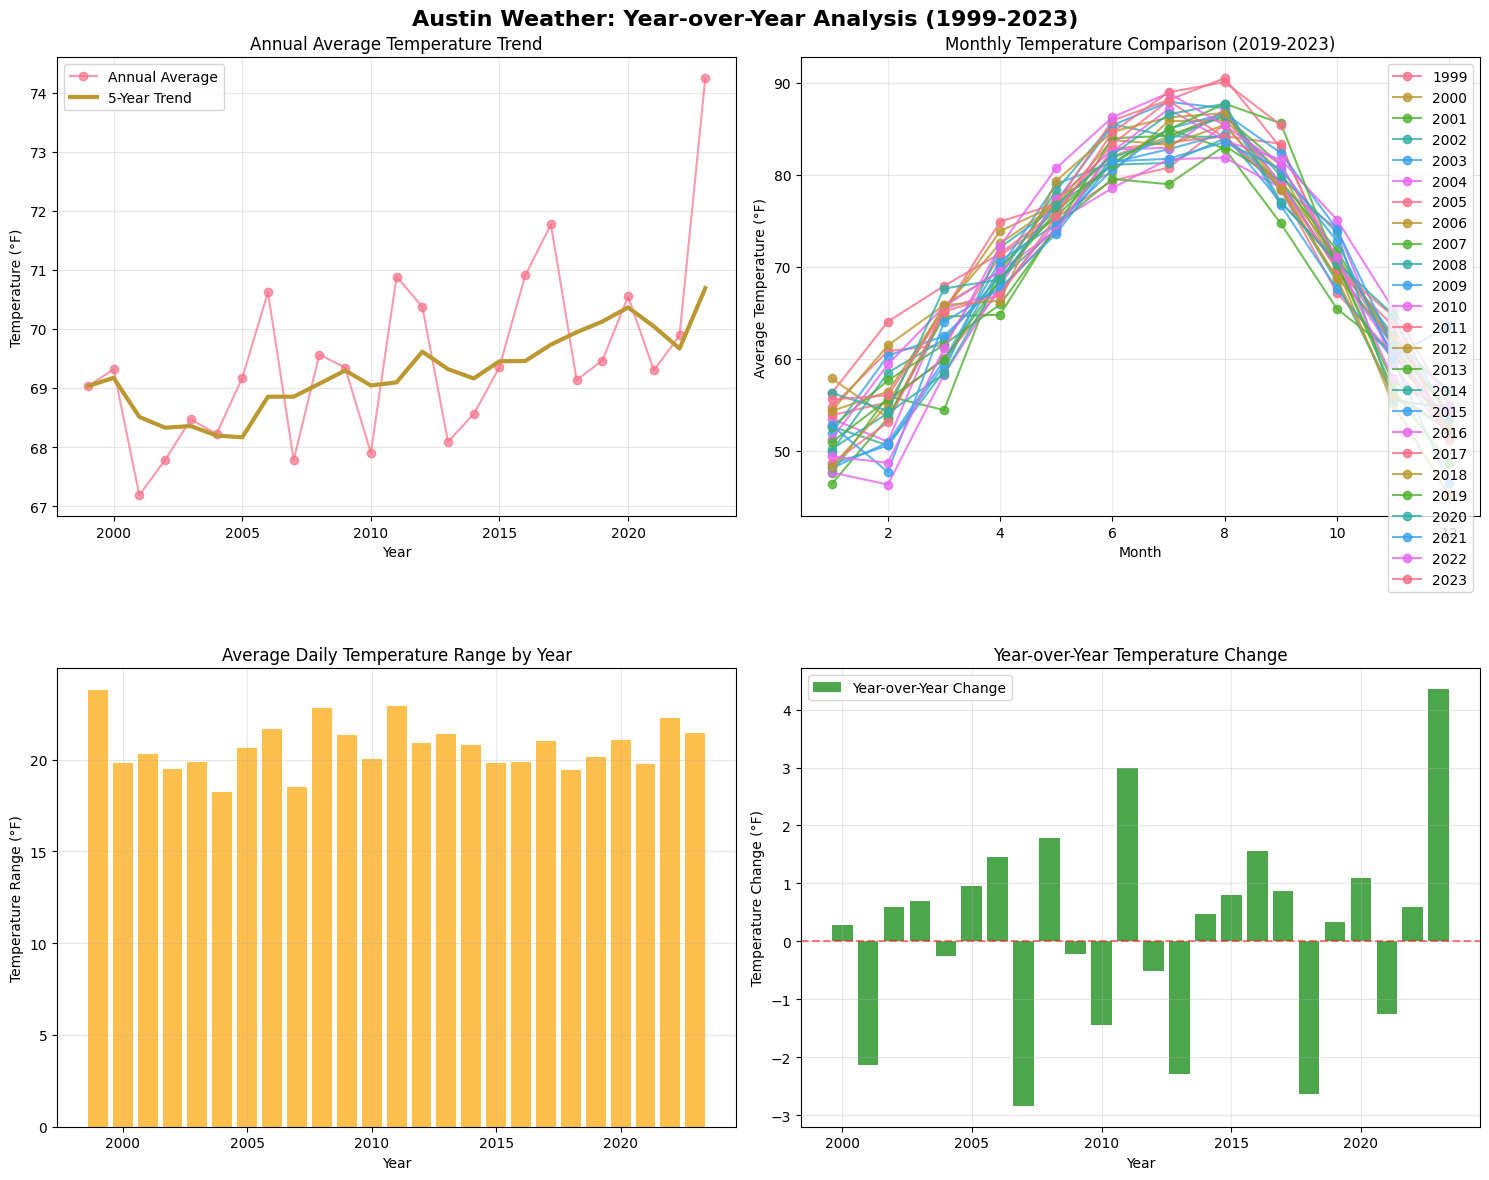

In [79]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Austin Weather: Year-over-Year Analysis (1999-2023)', fontsize=16, fontweight='bold')

# 1. Annual Average Temperature Trend
axes[0, 0].plot(annual_temps['Year'], annual_temps['TempAvgF'], 'o-', alpha=0.7, label='Annual Average')
axes[0, 0].plot(annual_temps['Year'], annual_temps['TempTrend'], '-', linewidth=3, label='5-Year Trend')
axes[0, 0].set_title('Annual Average Temperature Trend')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Temperature (°F)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Monthly Temperature Comparison (last 5 years)
# Not all years cause it looks messy
recent_years = monthly_comparison[monthly_comparison['Year'] >= 1999]
for year in recent_years['Year'].unique():
    year_data = recent_years[recent_years['Year'] == year]
    axes[0, 1].plot(year_data['Month'], year_data['TempAvgF'], 'o-', label=f'{year}', alpha=0.8)
axes[0, 1].set_title('Monthly Temperature Comparison (2019-2023)')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Average Temperature (°F)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Temperature Range Over Time
yearly_range = yoy_data.groupby('Year')['DailyTempRange'].mean().reset_index()
axes[1, 0].bar(yearly_range['Year'], yearly_range['DailyTempRange'], alpha=0.7, color='orange')
axes[1, 0].set_title('Average Daily Temperature Range by Year')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Temperature Range (°F)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Year-over-Year Temperature Change
axes[1, 1].bar(annual_temps['Year'][1:], annual_temps['YoY_Change'][1:],
               alpha=0.7, color='green', label='Year-over-Year Change')
axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].set_title('Year-over-Year Temperature Change')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Temperature Change (°F)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


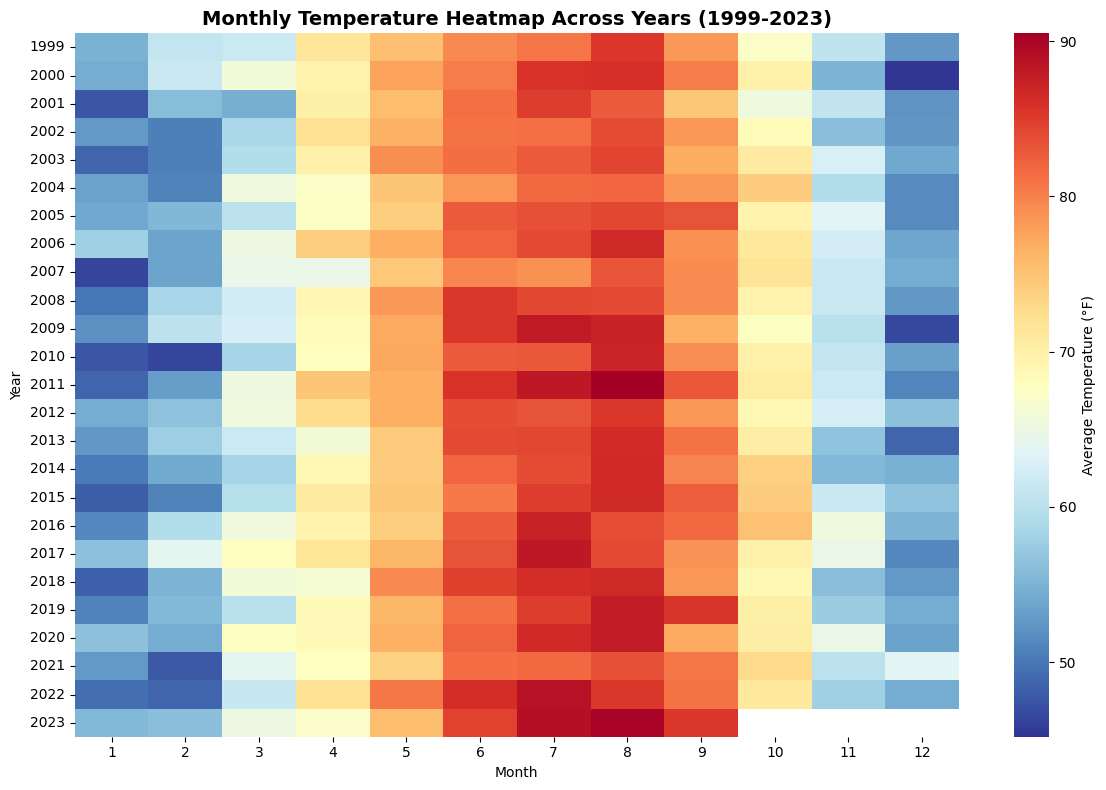

In [80]:
# Create a heatmap of monthly temperatures across years
plt.figure(figsize=(12, 8))

# Pivot data for heatmap
heatmap_data = monthly_comparison.pivot(index='Year', columns='Month', values='TempAvgF')

# Create heatmap
sns.heatmap(heatmap_data, annot=False, cmap='RdYlBu_r', cbar_kws={'label': 'Average Temperature (°F)'})
plt.title('Monthly Temperature Heatmap Across Years (1999-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()


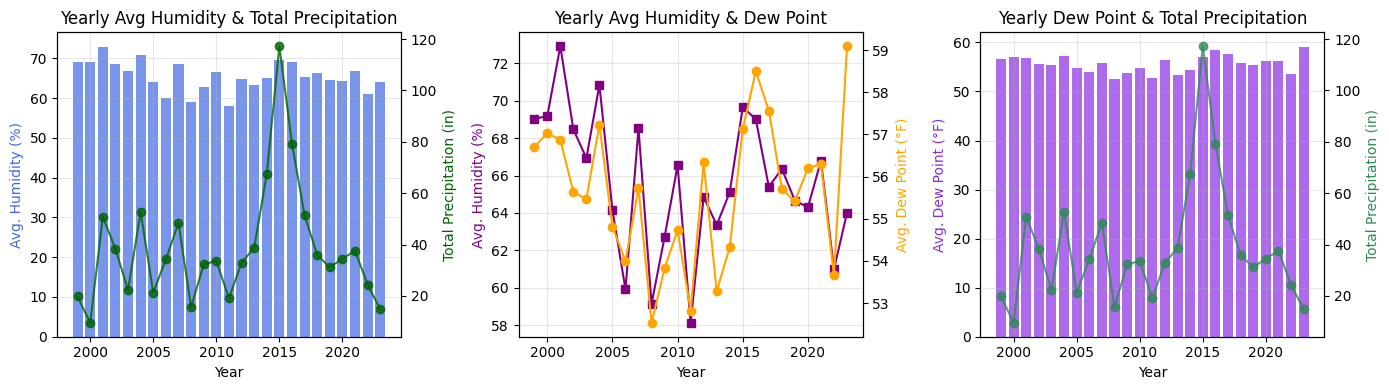

In [81]:
# Year-on-Year Analysis: Average Humidity, Dew Point, and Precipitation by Year

# Aggregate year-over-year data
yoy_year_summary = yoy_data.groupby('Year').agg({
    'HumidityAvgPercent': 'mean',
    'PrecipitationSumInches': 'sum',
    'DewPointAvgF': 'mean'
}).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Humidity vs. Precipitation (annual averages/sum by year)
axes[0].bar(yoy_year_summary['Year'], yoy_year_summary['HumidityAvgPercent'], color='royalblue', alpha=0.7, label='Avg. Humidity (%)')
ax2 = axes[0].twinx()
ax2.plot(yoy_year_summary['Year'], yoy_year_summary['PrecipitationSumInches'], color='darkgreen', marker='o', alpha=0.8, label='Total Precipitation (in)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Avg. Humidity (%)', color='royalblue')
ax2.set_ylabel('Total Precipitation (in)', color='darkgreen')
axes[0].set_title('Yearly Avg Humidity & Total Precipitation')
axes[0].grid(alpha=0.3)

# 2. Humidity vs. Dew Point (annual means)
axes[1].plot(yoy_year_summary['Year'], yoy_year_summary['HumidityAvgPercent'], color='purple', marker='s', label='Avg. Humidity (%)')
ax3 = axes[1].twinx()
ax3.plot(yoy_year_summary['Year'], yoy_year_summary['DewPointAvgF'], color='orange', marker='o', label='Avg. Dew Point (°F)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg. Humidity (%)', color='purple')
ax3.set_ylabel('Avg. Dew Point (°F)', color='orange')
axes[1].set_title('Yearly Avg Humidity & Dew Point')
axes[1].grid(alpha=0.3)

# 3. Dew Point vs. Precipitation (annual means/sum)
axes[2].bar(yoy_year_summary['Year'], yoy_year_summary['DewPointAvgF'], color='blueviolet', alpha=0.7, label='Avg. Dew Point (°F)')
ax4 = axes[2].twinx()
ax4.plot(yoy_year_summary['Year'], yoy_year_summary['PrecipitationSumInches'], color='seagreen', marker='o', alpha=0.8, label='Total Precipitation (in)')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Avg. Dew Point (°F)', color='blueviolet')
ax4.set_ylabel('Total Precipitation (in)', color='seagreen')
axes[2].set_title('Yearly Dew Point & Total Precipitation')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Step 9: Statistical Analysis of Temperature Changes


In [82]:
print("=== STATISTICAL ANALYSIS OF TEMPERATURE CHANGES ===")

# Calculate overall temperature trend
from scipy import stats

# Linear regression on annual temperatures
slope, intercept, r_value, p_value, std_err = stats.linregress(annual_temps['Year'], annual_temps['TempAvgF'])

print(f"Linear trend analysis:")
print(f"Slope (temperature change per year): {slope:.4f}°F/year")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Total change over 25 years: {slope * 25:.2f}°F")

# Calculate temperature statistics by decade
decade_stats = []
for decade in [1999, 2009, 2019]:
    decade_data = yoy_data[(yoy_data['Year'] >= decade) & (yoy_data['Year'] < decade + 10)]
    if len(decade_data) > 0:
        decade_stats.append({
            'Decade': f"{decade}s",
            'Avg_Temp': decade_data['TempAvgF'].mean(),
            'Max_Temp': decade_data['TempHighF'].max(),
            'Min_Temp': decade_data['TempLowF'].min(),
            'Temp_Range': decade_data['DailyTempRange'].mean()
        })

decade_df = pd.DataFrame(decade_stats)
print("\nTemperature statistics by decade:")
print(decade_df.round(2))

# Calculate hottest and coldest years
hottest_year = annual_temps.loc[annual_temps['TempAvgF'].idxmax()]
coldest_year = annual_temps.loc[annual_temps['TempAvgF'].idxmin()]

print(f"\nHottest year: {hottest_year['Year']} ({hottest_year['TempAvgF']:.2f}°F)")
print(f"Coldest year: {coldest_year['Year']} ({coldest_year['TempAvgF']:.2f}°F)")


=== STATISTICAL ANALYSIS OF TEMPERATURE CHANGES ===
Linear trend analysis:
Slope (temperature change per year): 0.1151°F/year
R-squared: 0.3139
P-value: 0.0036
Total change over 25 years: 2.88°F

Temperature statistics by decade:
  Decade  Avg_Temp  Max_Temp  Min_Temp  Temp_Range
0  1999s     68.71     109.8      21.4       20.52
1  2009s     69.71     110.4      16.1       20.65
2  2019s     70.49     108.1       8.2       20.92

Hottest year: 2023.0 (74.25°F)
Coldest year: 2001.0 (67.18°F)


## Step 10: Final Data Summary and Export


In [83]:
print("=== FINAL DATA SUMMARY ===")

print(f"Original dataset: {data.shape}")
print(f"Cleaned dataset: {data_features.shape}")
print(f"Features added: {data_features.shape[1] - data.shape[1]}")

print("\nData quality summary:")
print(f"Missing values: {data_features.isnull().sum().sum()}")
print(f"Date range: {data_features['Date'].min().strftime('%Y-%m-%d')} to {data_features['Date'].max().strftime('%Y-%m-%d')}")
print(f"Total days: {len(data_features)}")

print("\nTemperature statistics:")
print(f"Average temperature: {data_features['TempAvgF'].mean():.2f}°F")
print(f"Temperature range: {data_features['TempLowF'].min():.2f}°F to {data_features['TempHighF'].max():.2f}°F")
print(f"Average daily range: {data_features['DailyTempRange'].mean():.2f}°F")

print("\nData cleaning and feature engineering complete!")
print("Year-over-year analysis complete!")

# Export cleaned data
data_features.to_csv('Austin_Weather_Cleaned_99_23.csv', index=False)
print("\nCleaned data exported to 'Austin_Weather_Cleaned_99_23.csv'")


=== FINAL DATA SUMMARY ===
Original dataset: (10354, 10)
Cleaned dataset: (10354, 27)
Features added: 17

Data quality summary:
Missing values: 2
Date range: 1999-01-01 to 2023-09-26
Total days: 10354

Temperature statistics:
Average temperature: 69.49°F
Temperature range: 8.20°F to 110.40°F
Average daily range: 20.65°F

Data cleaning and feature engineering complete!
Year-over-year analysis complete!

Cleaned data exported to 'Austin_Weather_Cleaned_99_23.csv'


# 10/12 Deliverables

Implementation:
### Correlation Analysis

The correlation analysis involves examining the relationships between different weather variables in the Austin dataset. The key feature is that I wrote a two-stage approach to the program to analyze the relationships between the variables:

1. Spearman Correlation: this method is used to identify monotonic relationships between variables, which is particularly useful for non-linear data.
2. Pearson Correlation: this method is used to identify linear relationships between variables.

By writing this script, I was able to identify significant correlations between various weather parameters, which can provide insights into how different factors interact with each other in the context of Austin's climate.

### Outlier Detection

Outlier detection is crucial for ensuring the integrity of the dataset. In this implementation, I utilized the Interquartile Range (IQR) method to identify and handle outliers in the weather data. The key features of this implementation include:

1. Calculation of Q1 and Q3: The first and third quartiles are calculated to determine the IQR.
2. Outlier Identification: Data points that fall below Q1 - (1.5 x IQR) or above Q3 + (1.5 x IQR) are flagged as outliers.
3. Handling Outliers: Depending on the analysis requirements, outliers can be removed or transformed to minimize their impact on the results.

These implementations enhance the overall analysis of the Austin weather dataset by ensuring that relationships between variables are accurately captured and that anomalies in the data do not skew the results. It also allows us to check for any unusual weather patterns that may need further investigation.

## 1. Correlation Analysis

=== CORRELATION ANALYSIS ===

Excluding polynomial columns from correlation: ['TempAvgF_squared', 'HumidityAvgPercent_squared', 'Pressure_squared']
Number of numeric columns identified: 19
Numeric columns: ['TempHighF', 'TempLowF', 'TempAvgF', 'DewPointAvgF', 'HumidityAvgPercent', 'sealevelpressure', 'VisibilityAvgMiles', 'PrecipitationSumInches', 'Year', 'Month', 'Day', 'DayOfYear', 'DailyTempRange', 'HeatIndex', 'TempPressure', 'PrevDayTemp', 'PrevDayHumidity', 'TempAvg_7day', 'HumidityAvg_7day']
Final numeric columns for analysis: 19

=== SPEARMAN CORRELATION ANALYSIS ===
Spearman correlation matrix computed successfully


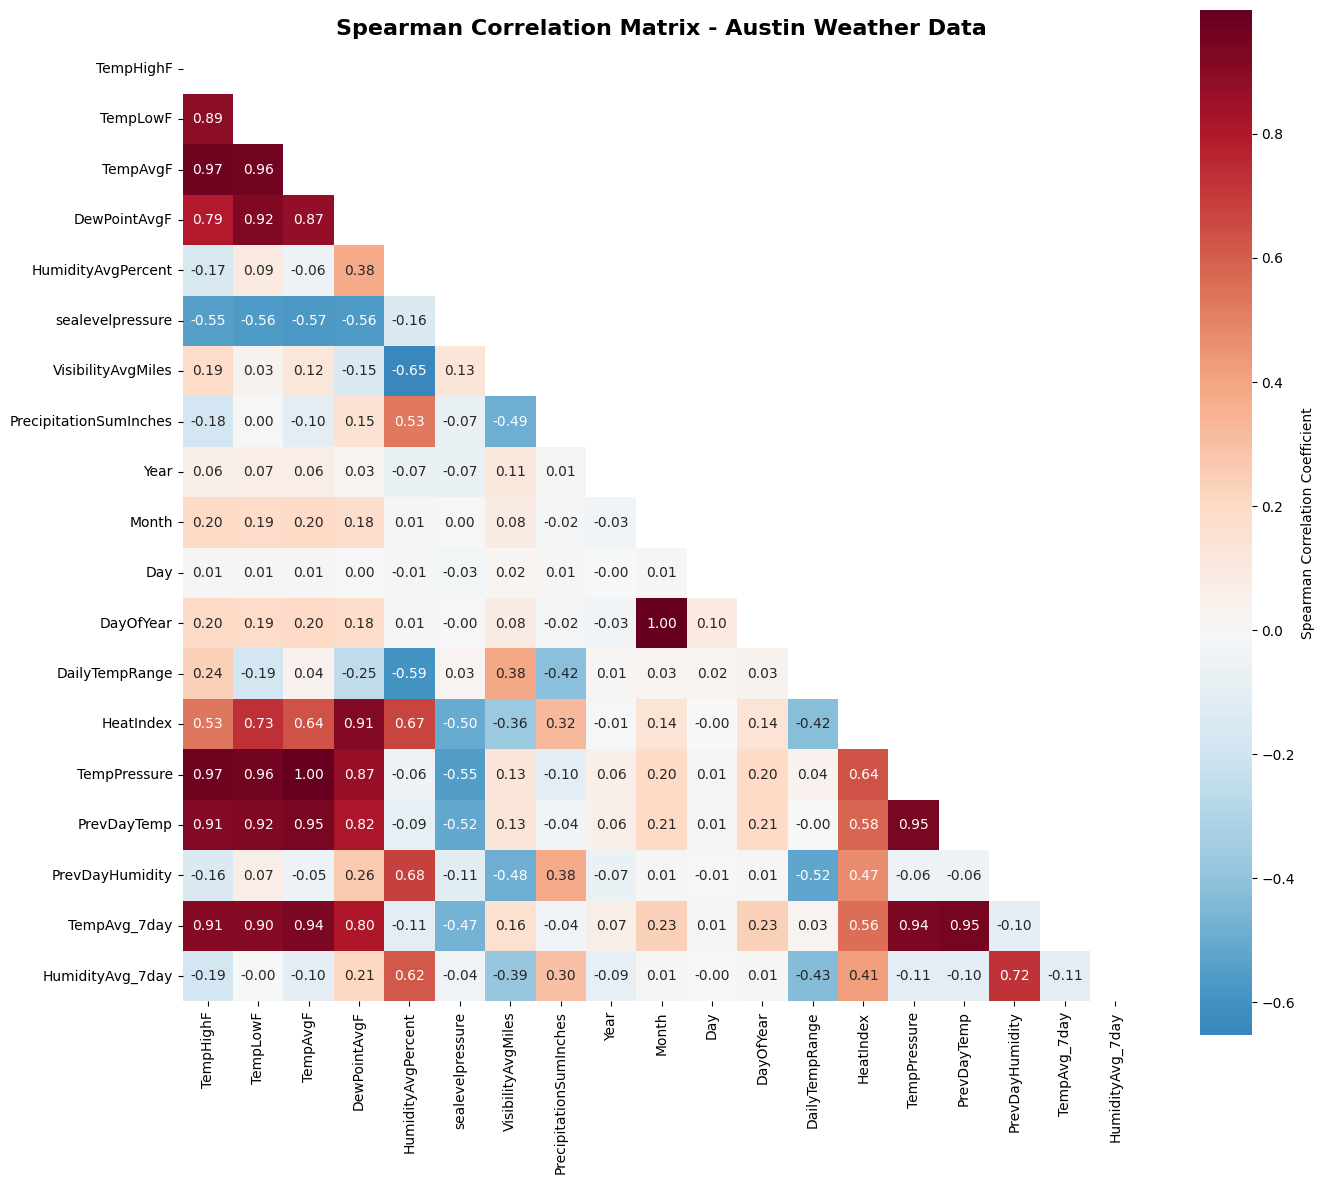


=== FILTERING STRONG MONOTONIC RELATIONSHIPS ===
Found 25 strong monotonic relationships (|r| >= 0.7)

Strong monotonic pairs:
         Variable_1        Variable_2  Spearman_Correlation
13         TempAvgF      TempPressure              0.999750
20            Month         DayOfYear              0.996505
1         TempHighF          TempAvgF              0.971842
3         TempHighF      TempPressure              0.971651
6          TempLowF          TempAvgF              0.963933
9          TempLowF      TempPressure              0.963413
23      PrevDayTemp      TempAvg_7day              0.952228
21     TempPressure       PrevDayTemp              0.946878
14         TempAvgF       PrevDayTemp              0.946545
22     TempPressure      TempAvg_7day              0.936814
15         TempAvgF      TempAvg_7day              0.935477
10         TempLowF       PrevDayTemp              0.923442
7          TempLowF      DewPointAvgF              0.921131
16     DewPointAvgF         Heat

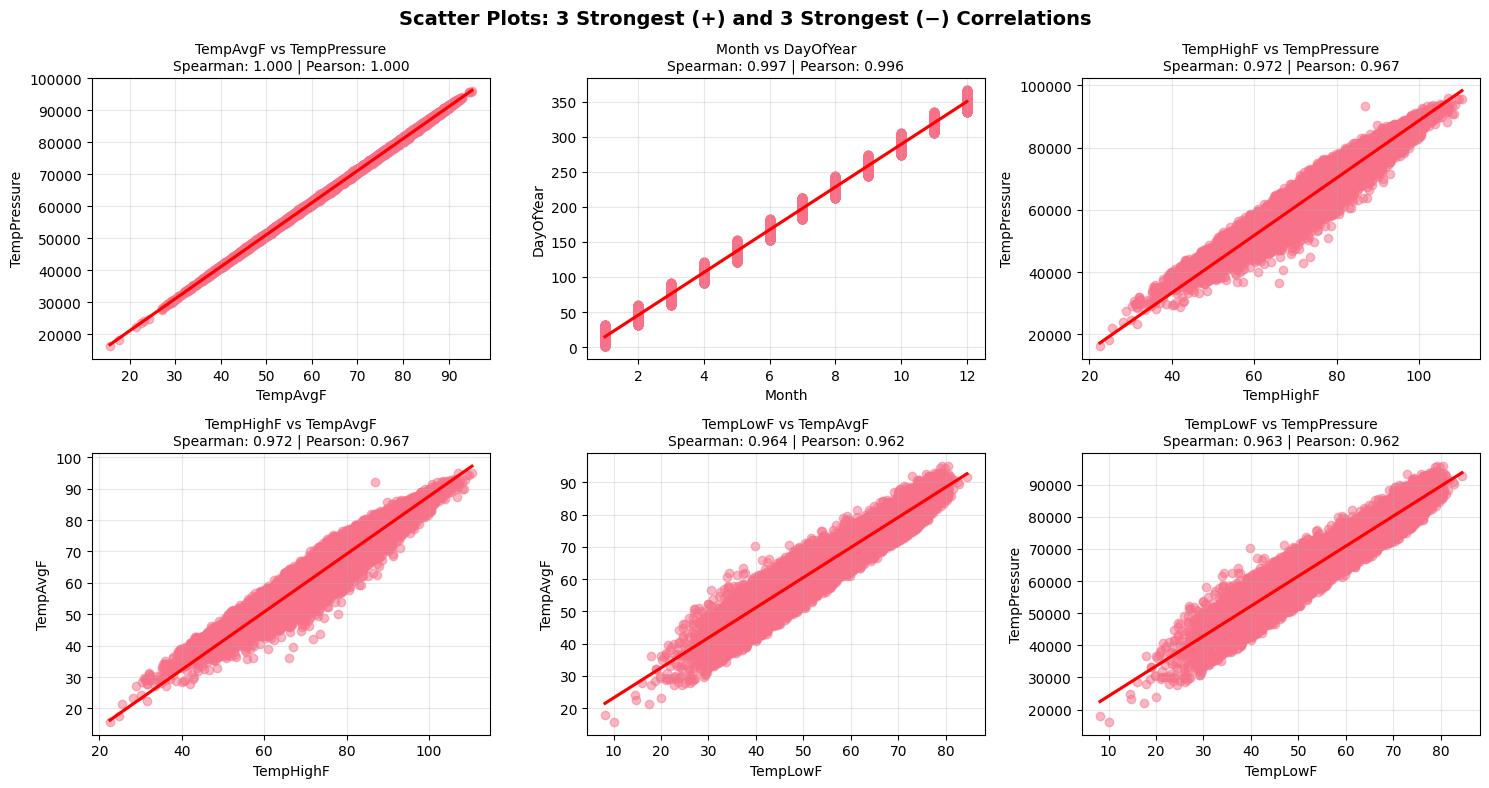


=== EXPORTING RESULTS ===
Saved: spearman_correlation_matrix.csv
Saved: strong_correlations_summary.csv

Analysis complete! Found 25 significant relationships.

Correlation analysis finished successfully!


In [ ]:
print("=== CORRELATION ANALYSIS ===")

# Step 1: Data Selection
# Load the cleaned dataset if not already in memory
if 'data_features' not in globals():
    data_features = pd.read_csv('Austin_Weather_Cleaned_99_23.csv')
    # Convert Date column back to datetime if needed
    if 'Date' in data_features.columns:
        data_features['Date'] = pd.to_datetime(data_features['Date'])

# Select only numerical columns
numeric_df = data_features.select_dtypes(include=[np.number]).copy()
# Drop polynomial expansion columns from correlation analysis
squared_cols = [col for col in numeric_df.columns if col.endswith('_squared')]
if squared_cols:
    print(f"\nExcluding polynomial columns from correlation: {squared_cols}")
    numeric_df = numeric_df.drop(columns=squared_cols)

print(f"Number of numeric columns identified: {len(numeric_df.columns)}")
print(f"Numeric columns: {list(numeric_df.columns)}")

# Remove columns with very low variance (optional cleanup)
low_variance_threshold = 0.01
variance_check = numeric_df.var()
low_var_cols = variance_check[variance_check < low_variance_threshold].index
if len(low_var_cols) > 0:
    print(f"\nRemoving low variance columns: {list(low_var_cols)}")
    numeric_df = numeric_df.drop(columns=low_var_cols)

print(f"Final numeric columns for analysis: {len(numeric_df.columns)}")

# Step 2: Compute Spearman Correlation Matrix
print("\n=== SPEARMAN CORRELATION ANALYSIS ===")
spearman_corr = numeric_df.corr(method='spearman')
print("Spearman correlation matrix computed successfully")

# Visualize Spearman correlation matrix
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))  # Hide upper triangle
sns.heatmap(spearman_corr,
            mask=mask,
            annot=True,
            cmap='RdBu_r',
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={'label': 'Spearman Correlation Coefficient'})
plt.title('Spearman Correlation Matrix - Austin Weather Data', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Step 3: Filter Strong Relationships (|r| >= 0.7)
print("\n=== FILTERING STRONG MONOTONIC RELATIONSHIPS ===")
strong_threshold = 0.7

# Extract strong correlations (excluding diagonal)
strong_pairs = []
n = len(spearman_corr.columns)

for i in range(n):
    for j in range(i+1, n):
        var1 = spearman_corr.columns[i]
        var2 = spearman_corr.columns[j]
        spearman_val = spearman_corr.iloc[i, j]

        if abs(spearman_val) >= strong_threshold:
            strong_pairs.append({
                'Variable_1': var1,
                'Variable_2': var2,
                'Spearman_Correlation': spearman_val
            })

print(f"Found {len(strong_pairs)} strong monotonic relationships (|r| >= {strong_threshold})")

if len(strong_pairs) > 0:
    strong_pairs_df = pd.DataFrame(strong_pairs)
    print("\nStrong monotonic pairs:")
    print(strong_pairs_df.sort_values('Spearman_Correlation', key=abs, ascending=False))
else:
    print("No strong monotonic relationships found with the current threshold.")
    # Lower threshold for demonstration
    strong_threshold = 0.5
    print(f"\nLowering threshold to {strong_threshold} for analysis...")

    for i in range(n):
        for j in range(i+1, n):
            var1 = spearman_corr.columns[i]
            var2 = spearman_corr.columns[j]
            spearman_val = spearman_corr.iloc[i, j]

            if abs(spearman_val) >= strong_threshold:
                strong_pairs.append({
                    'Variable_1': var1,
                    'Variable_2': var2,
                    'Spearman_Correlation': spearman_val
                })

    if len(strong_pairs) > 0:
        strong_pairs_df = pd.DataFrame(strong_pairs)
        print(f"\nFound {len(strong_pairs)} moderate-to-strong relationships (|r| >= {strong_threshold})")
        print(strong_pairs_df.sort_values('Spearman_Correlation', key=abs, ascending=False))

# Step 4: Apply Pearson Correlation to Strong Pairs
if len(strong_pairs) > 0:
    print(f"\n=== PEARSON CORRELATION FOR STRONG PAIRS ===")

    # Add Pearson correlation and relationship classification
    for i, pair in enumerate(strong_pairs):
        var1, var2 = pair['Variable_1'], pair['Variable_2']

        # Compute Pearson correlation for this pair
        pair_data = numeric_df[[var1, var2]].dropna()
        pearson_val = pair_data.corr(method='pearson').iloc[0, 1]

        # Classify relationship type
        spear_abs = abs(pair['Spearman_Correlation'])
        pear_abs = abs(pearson_val)

        if pear_abs >= 0.7 and abs(spear_abs - pear_abs) <= 0.1:
            relationship_type = "Strong monotonic, linear"
        elif spear_abs >= 0.7 and pear_abs < 0.7:
            relationship_type = "Strong monotonic, nonlinear"
        elif spear_abs >= 0.7 and pear_abs >= 0.7:
            relationship_type = "Strong monotonic, mostly linear"
        else:
            relationship_type = "Moderate monotonic"

        strong_pairs[i]['Pearson_Correlation'] = pearson_val
        strong_pairs[i]['Relationship_Type'] = relationship_type

    # Create final summary table
    summary_df = pd.DataFrame(strong_pairs)
    summary_df = summary_df.sort_values('Spearman_Correlation', key=abs, ascending=False)

    print("Summary of Strong Relationships:")
    print("=" * 80)
    for _, row in summary_df.iterrows():
        print(f"{row['Variable_1']} ↔ {row['Variable_2']}")
        print(f"  Spearman: {row['Spearman_Correlation']:.3f}")
        print(f"  Pearson:  {row['Pearson_Correlation']:.3f}")
        print(f"  Type:     {row['Relationship_Type']}")
        print()

# Step 5: Visualization of Strongest and Weakest Pairs
if len(strong_pairs) > 0:
    print("=== SCATTER PLOTS: 3 STRONGEST (+) AND 3 STRONGEST (−) ===")

    # Determine initial candidates from strong pairs (by Pearson)
    df_for_plot = summary_df.copy().dropna(subset=['Pearson_Correlation'])
    pos = df_for_plot[df_for_plot['Pearson_Correlation'] >= 0].sort_values('Pearson_Correlation', ascending=False).head(3)
    neg = df_for_plot[df_for_plot['Pearson_Correlation'] < 0].sort_values('Pearson_Correlation', ascending=True).head(3)
    combined = pd.concat([pos, neg], ignore_index=True)

    # Build set of selected keys (order-independent) to avoid duplicates later
    selected_keys = set(tuple(sorted((r['Variable_1'], r['Variable_2']))) for _, r in combined.iterrows())

    # If fewer than 6, backfill from global Pearson extremes (not limited by Spearman threshold)
    needed = 6 - len(combined)
    if needed > 0:
        pearson_corr = numeric_df.corr(method='pearson')
        all_pairs = []
        cols = list(pearson_corr.columns)
        for i in range(len(cols)):
            for j in range(i+1, len(cols)):
                v1, v2 = cols[i], cols[j]
                key = tuple(sorted((v1, v2)))
                r = pearson_corr.iloc[i, j]
                if pd.notna(r) and key not in selected_keys:
                    all_pairs.append({'Variable_1': v1, 'Variable_2': v2, 'Pearson_Correlation': r})
        all_pairs_df = pd.DataFrame(all_pairs)
        if not all_pairs_df.empty:
            # Fill remaining slots by absolute Pearson strength
            filler = all_pairs_df.reindex(all_pairs_df['Pearson_Correlation'].abs().sort_values(ascending=False).index).head(needed)
            # Attach Spearman values from the already computed matrix
            if not filler.empty:
                filler['Spearman_Correlation'] = filler.apply(lambda r: spearman_corr.loc[r['Variable_1'], r['Variable_2']], axis=1)
                filler['Relationship_Type'] = 'Added by global Pearson'
                combined = pd.concat([combined, filler], ignore_index=True)

    # If still empty (very edge case), skip plotting safely
    n_plots = len(combined)
    if n_plots > 0:
        cols = min(3, n_plots)
        rows = int(np.ceil(n_plots / cols))

        fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
        if rows == 1 and cols == 1:
            axes = [axes]
        elif rows == 1:
            axes = axes if isinstance(axes, (list, np.ndarray)) else [axes]
        else:
            axes = axes.flatten()

        for idx, (_, row) in enumerate(combined.iterrows()):
            if idx >= len(axes):
                break

            var1, var2 = row['Variable_1'], row['Variable_2']
            # Look up latest coefficients for title (fall back if missing)
            spear_r = row.get('Spearman_Correlation', spearman_corr.loc[var1, var2])
            pear_r = row.get('Pearson_Correlation', numeric_df[[var1, var2]].corr(method='pearson').iloc[0, 1])

            # Create scatter plot with regression line
            pair_data = numeric_df[[var1, var2]].dropna()
            sns.regplot(data=pair_data, x=var1, y=var2, ax=axes[idx],
                       scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})

            axes[idx].set_title(f'{var1} vs {var2}\n'
                               f'Spearman: {spear_r:.3f} | Pearson: {pear_r:.3f}',
                               fontsize=10)
            axes[idx].grid(True, alpha=0.3)

        # Hide unused subplots
        for idx in range(n_plots, len(axes)):
            axes[idx].set_visible(False)

        plt.suptitle('Scatter Plots: 3 Strongest (+) and 3 Strongest (−) Correlations', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

# Step 6: Export Results
print("\n=== EXPORTING RESULTS ===")

# Save correlation matrices
spearman_corr.to_csv('spearman_correlation_matrix.csv')
print("Saved: spearman_correlation_matrix.csv")

# Save summary of strong relationships
if len(strong_pairs) > 0:
    summary_df.to_csv('strong_correlations_summary.csv', index=False)
    print("Saved: strong_correlations_summary.csv")

    print(f"\nAnalysis complete! Found {len(strong_pairs)} significant relationships.")
else:
    print("No strong correlations found to export.")

print("\nCorrelation analysis finished successfully!")

## 2. Outlier Detection

=== OUTLIER DETECTION ANALYSIS ===
=== DATA PREPARATION ===
Excluding polynomial columns from outlier detection: ['TempAvgF_squared', 'HumidityAvgPercent_squared', 'Pressure_squared']
Columns selected for outlier detection: 15
Selected columns: ['TempHighF', 'TempLowF', 'TempAvgF', 'DewPointAvgF', 'HumidityAvgPercent', 'sealevelpressure', 'VisibilityAvgMiles', 'PrecipitationSumInches', 'DailyTempRange', 'HeatIndex', 'TempPressure', 'PrevDayTemp', 'PrevDayHumidity', 'TempAvg_7day', 'HumidityAvg_7day']
Handling 2 missing values...
Missing values after imputation: 0
Dataset shape for outlier analysis: (10354, 15)

=== UNIVARIATE OUTLIER DETECTION (IQR METHOD) ===
Univariate Outlier Summary (Top 10 by percentage):
                  Variable  Lower_Bound  Upper_Bound  Outlier_Count  \
7   PrecipitationSumInches        -0.01         0.01           2309   
6       VisibilityAvgMiles         7.65        11.25            995   
5         sealevelpressure      1002.25      1029.85            296

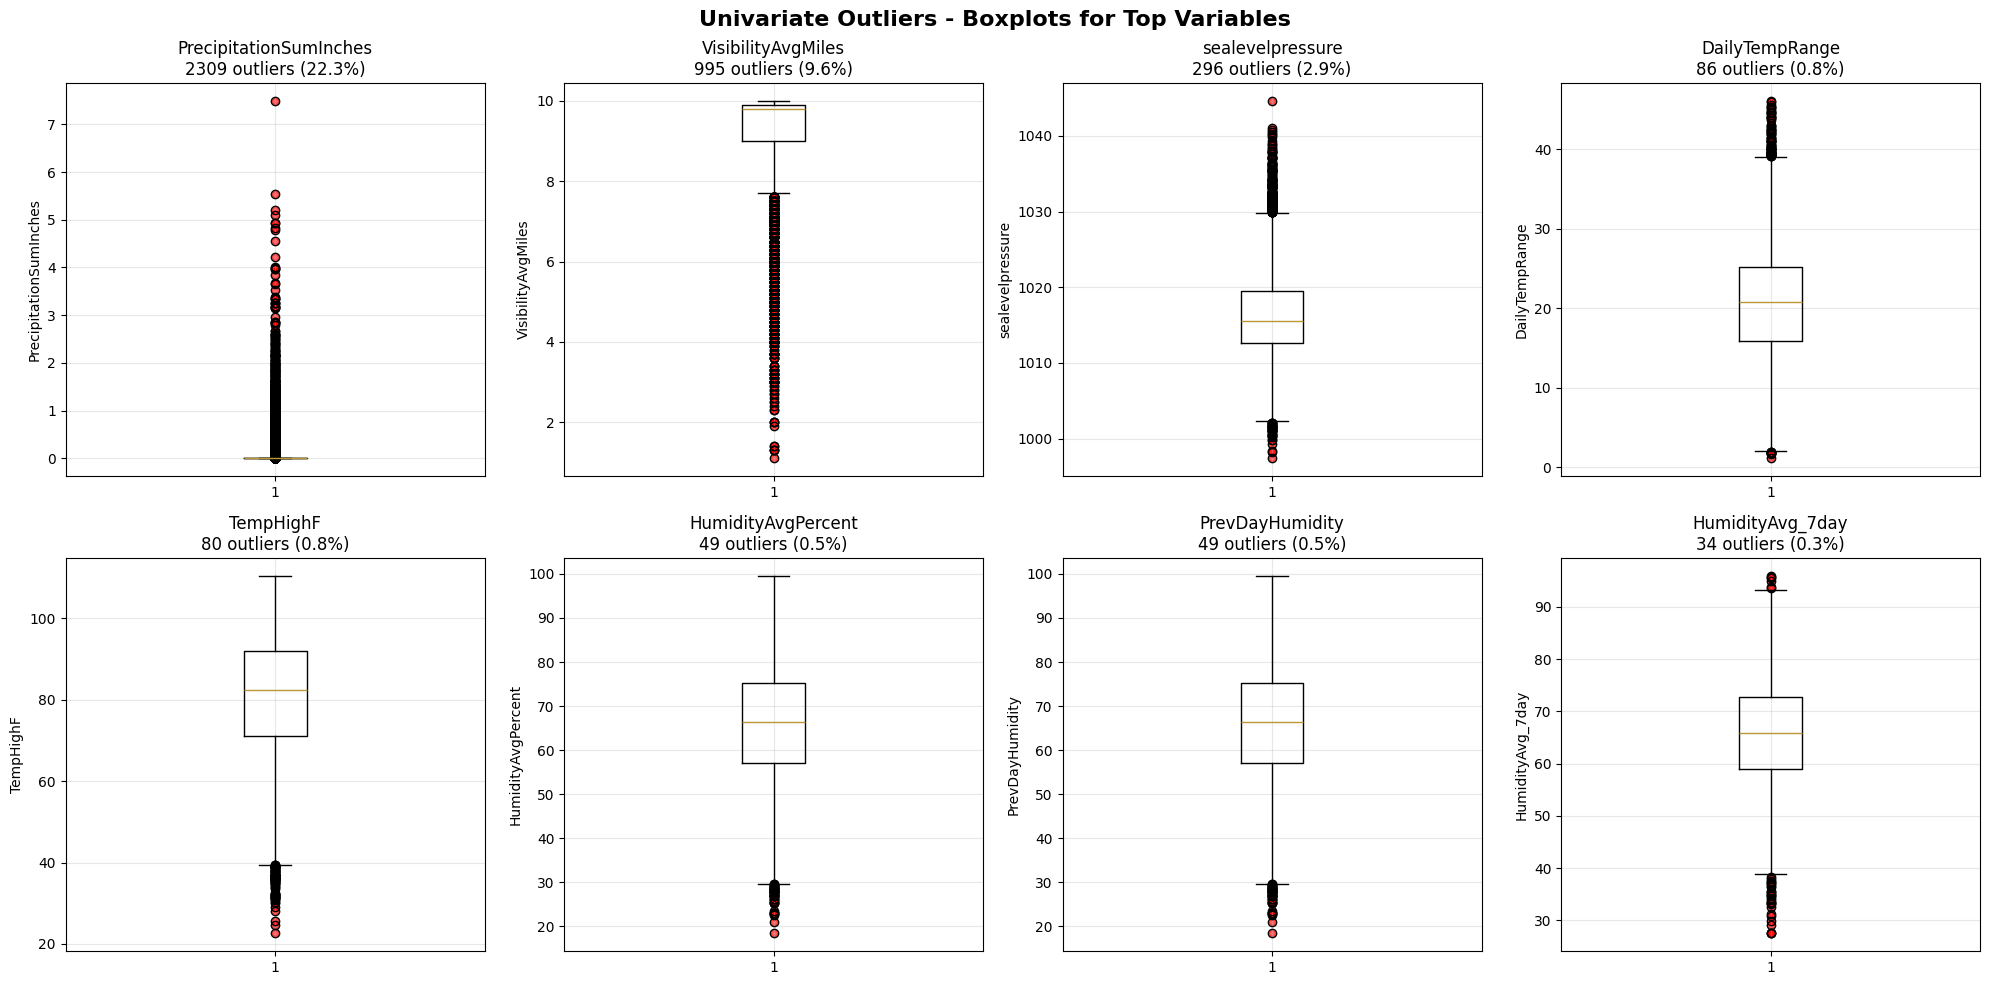


=== MULTIVARIATE OUTLIER DETECTION (ISOLATION FOREST) ===
Using contamination rate: 0.010
Multivariate outliers detected: 104 (1.00%)

=== MULTIVARIATE OUTLIER VISUALIZATION ===


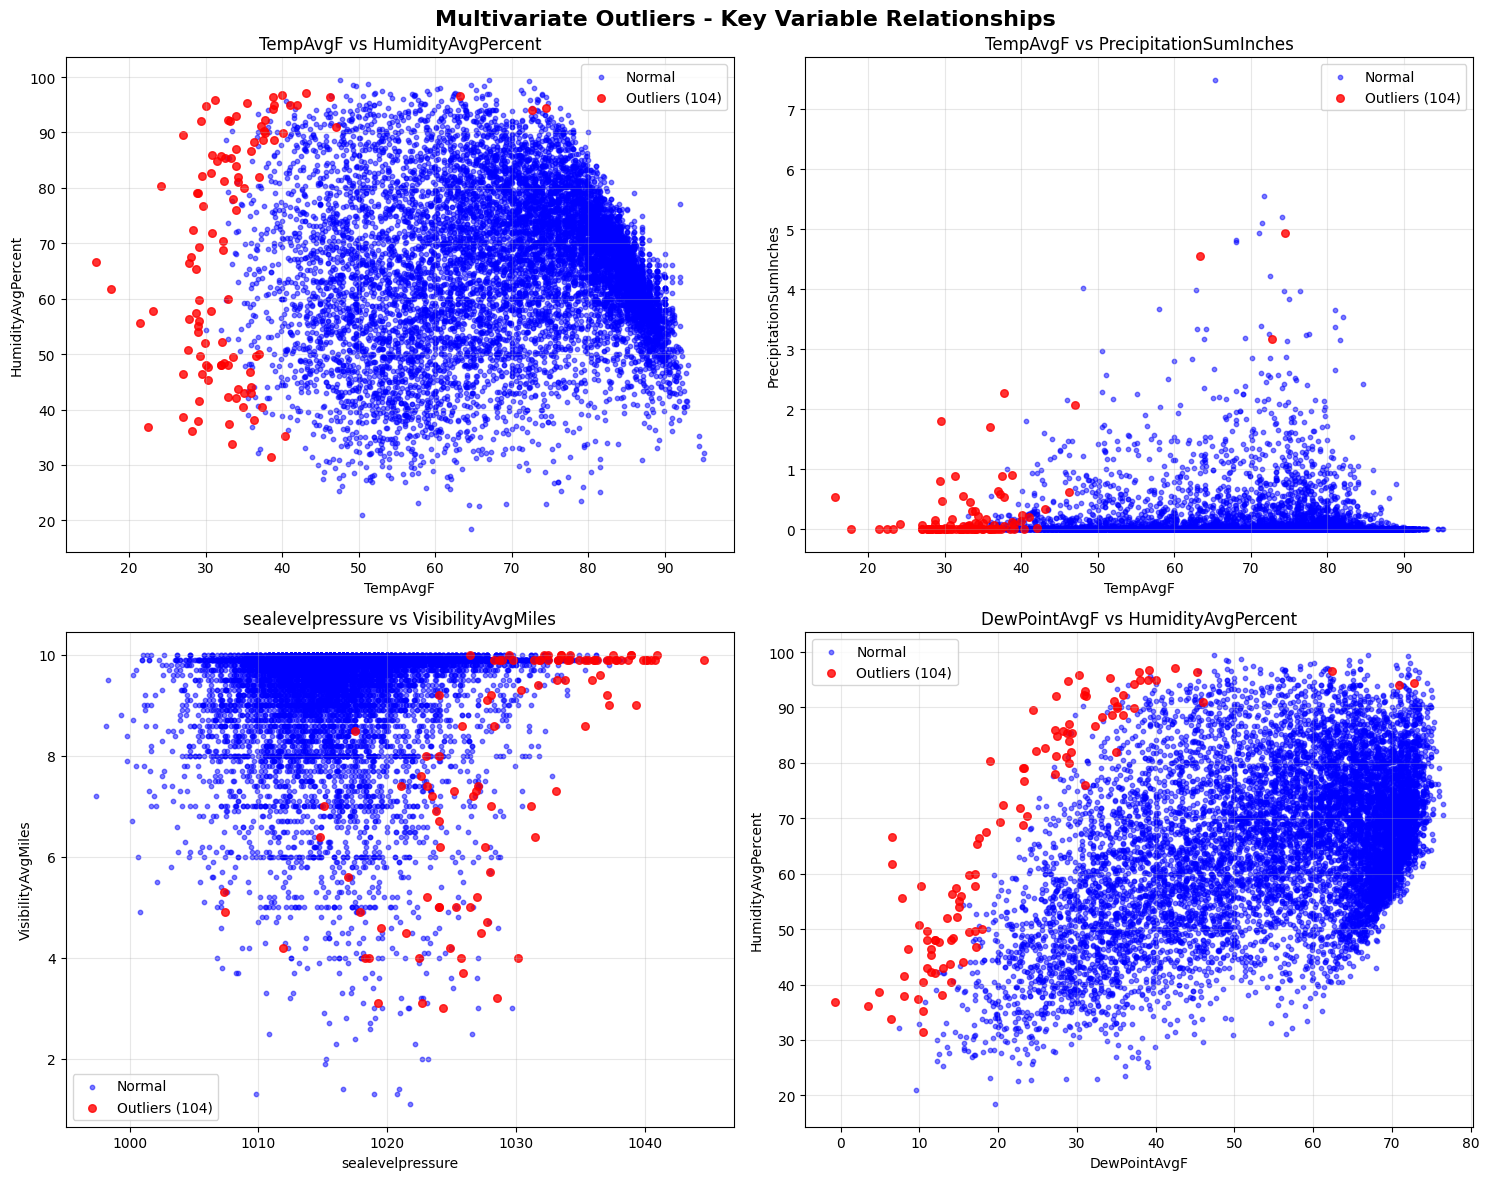


=== CONTEXT VALIDATION ===


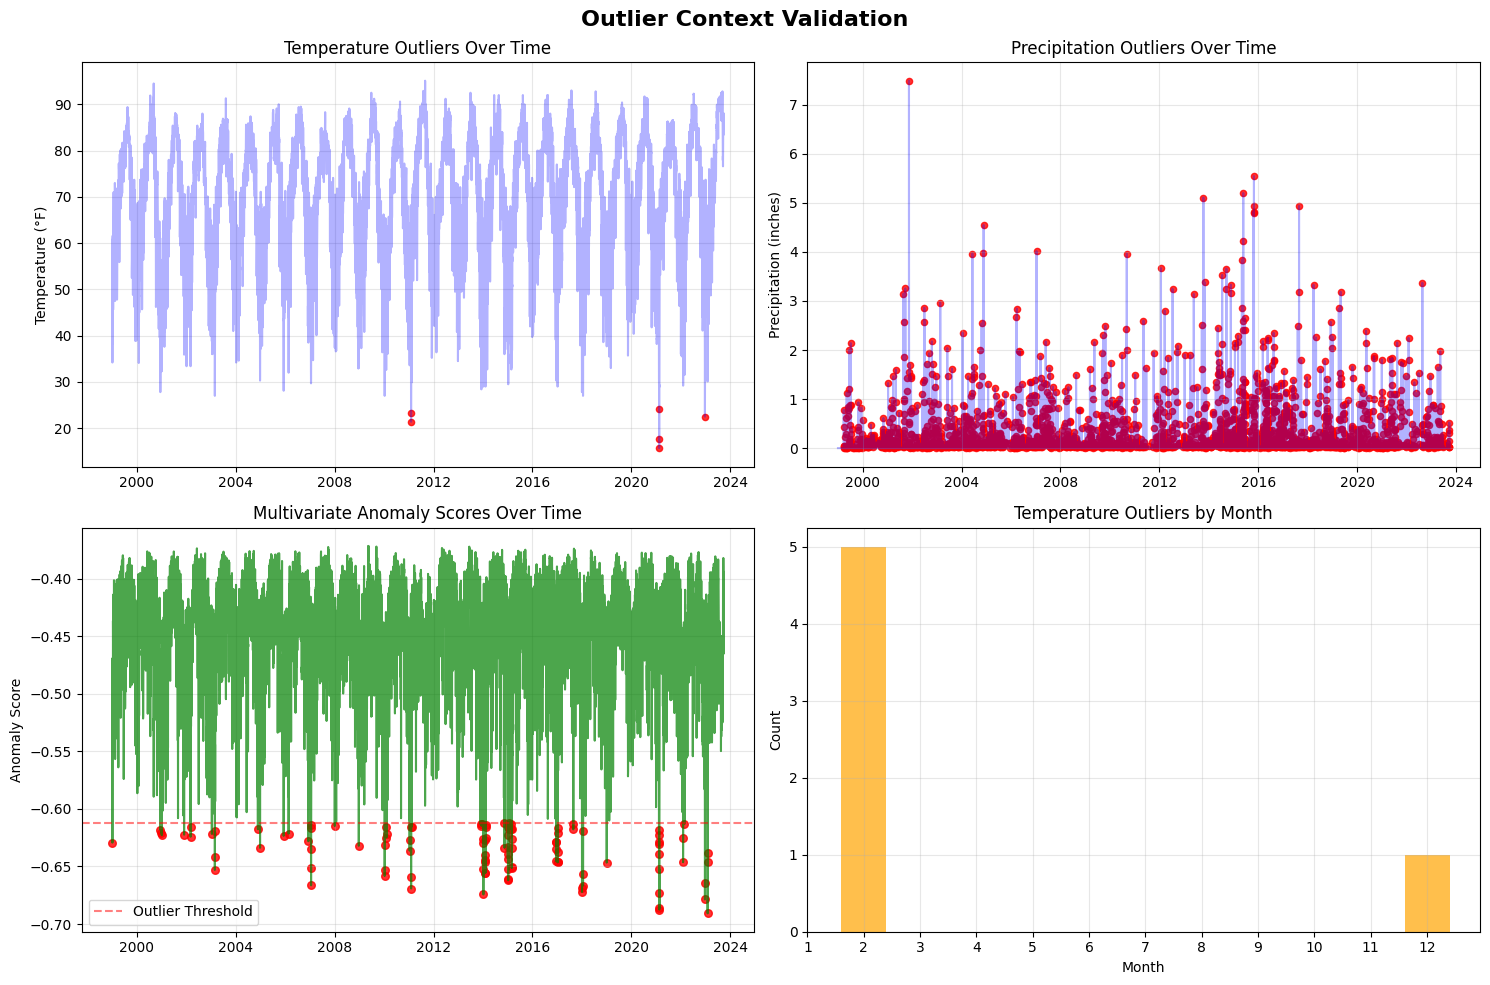


=== OUTLIER ANALYSIS SUMMARY ===
Outlier Detection Summary:
               Detection_Method               Variable  Outlier_Count  Percentage  Status
               Univariate (IQR) PrecipitationSumInches           2309   22.300560 Flagged
               Univariate (IQR)     VisibilityAvgMiles            995    9.609813 Flagged
               Univariate (IQR)       sealevelpressure            296    2.858799 Flagged
               Univariate (IQR)         DailyTempRange             86    0.830597  Review
               Univariate (IQR)              TempHighF             80    0.772648  Review
               Univariate (IQR)     HumidityAvgPercent             49    0.473247  Review
               Univariate (IQR)        PrevDayHumidity             49    0.473247  Review
               Univariate (IQR)       HumidityAvg_7day             34    0.328376  Review
               Univariate (IQR)           DewPointAvgF             12    0.115897  Review
               Univariate (IQR)        

In [ ]:
print("=== OUTLIER DETECTION ANALYSIS ===")

# Import additional libraries for outlier detection
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Step 1: Data Preparation
print("=== DATA PREPARATION ===")

# Load the cleaned dataset if not already in memory
if 'data_features' not in globals():
    data_features = pd.read_csv('Austin_Weather_Cleaned_99_23.csv')
    # Convert Date column back to datetime if needed
    if 'Date' in data_features.columns:
        data_features['Date'] = pd.to_datetime(data_features['Date'])

# Select only numerical columns for outlier analysis
outlier_df = data_features.select_dtypes(include=[np.number]).copy()

# Remove columns that shouldn't be analyzed for outliers (IDs, dates converted to numbers, etc.)
exclude_cols = ['Year', 'Month', 'Day', 'DayOfYear']  # Time-based features are expected to have ranges
squared_cols = [col for col in outlier_df.columns if col.endswith('_squared')]
if squared_cols:
    print(f"Excluding polynomial columns from outlier detection: {squared_cols}")
    exclude_cols.extend(squared_cols)
outlier_df = outlier_df.drop(columns=[col for col in exclude_cols if col in outlier_df.columns])

print(f"Columns selected for outlier detection: {len(outlier_df.columns)}")
print(f"Selected columns: {list(outlier_df.columns)}")

# Handle missing values (minimal imputation)
missing_before = outlier_df.isnull().sum().sum()
if missing_before > 0:
    print(f"Handling {missing_before} missing values...")
    # Forward fill then backward fill for weather data continuity
    outlier_df = outlier_df.fillna(method='ffill').fillna(method='bfill')
    missing_after = outlier_df.isnull().sum().sum()
    print(f"Missing values after imputation: {missing_after}")

print(f"Dataset shape for outlier analysis: {outlier_df.shape}")

# Step 2: Univariate Outlier Detection (IQR Method)
print("\n=== UNIVARIATE OUTLIER DETECTION (IQR METHOD) ===")

def detect_outliers_iqr(series, multiplier=1.5):
    """Detect outliers using IQR method"""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR

    outliers = (series < lower_bound) | (series > upper_bound)

    return {
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_indices': series[outliers].index,
        'outlier_count': outliers.sum(),
        'outlier_percentage': (outliers.sum() / len(series)) * 100
    }

# Apply IQR method to each column
iqr_results = {}
univariate_summary = []

for col in outlier_df.columns:
    result = detect_outliers_iqr(outlier_df[col])
    iqr_results[col] = result

    univariate_summary.append({
        'Variable': col,
        'Lower_Bound': result['lower_bound'],
        'Upper_Bound': result['upper_bound'],
        'Outlier_Count': result['outlier_count'],
        'Outlier_Percentage': result['outlier_percentage'],
        'Min_Value': outlier_df[col].min(),
        'Max_Value': outlier_df[col].max()
    })

# Create summary DataFrame
univariate_df = pd.DataFrame(univariate_summary)
univariate_df = univariate_df.sort_values('Outlier_Percentage', ascending=False)

print("Univariate Outlier Summary (Top 10 by percentage):")
print(univariate_df.head(10).round(2))

# Visualization: Boxplots for variables with highest outlier percentages
top_outlier_vars = univariate_df.head(8)['Variable'].tolist()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, var in enumerate(top_outlier_vars):
    if i < len(axes):
        outlier_indices = iqr_results[var]['outlier_indices']

        # Create boxplot
        axes[i].boxplot(outlier_df[var], vert=True)

        # Highlight outliers
        if len(outlier_indices) > 0:
            outlier_values = outlier_df.loc[outlier_indices, var]
            axes[i].scatter([1] * len(outlier_values), outlier_values,
                           color='red', alpha=0.6, s=20, label=f'Outliers ({len(outlier_values)})')

        axes[i].set_title(f'{var}\n{iqr_results[var]["outlier_count"]} outliers ({iqr_results[var]["outlier_percentage"]:.1f}%)')
        axes[i].set_ylabel(var)
        axes[i].grid(True, alpha=0.3)

# Hide unused subplots
for i in range(len(top_outlier_vars), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Univariate Outliers - Boxplots for Top Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Step 3: Multivariate Outlier Detection (Isolation Forest)
print("\n=== MULTIVARIATE OUTLIER DETECTION (ISOLATION FOREST) ===")

# Standardize features for Isolation Forest
scaler = StandardScaler()
outlier_scaled = scaler.fit_transform(outlier_df)

# Apply Isolation Forest
# Contamination rate based on dataset size - typically 1-5%
contamination_rate = min(0.05, max(0.01, 100 / len(outlier_df)))
print(f"Using contamination rate: {contamination_rate:.3f}")

iso_forest = IsolationForest(
    contamination=contamination_rate,
    random_state=42,
    n_estimators=100
)

# Fit and predict
multivariate_outliers = iso_forest.fit_predict(outlier_scaled)
multivariate_scores = iso_forest.score_samples(outlier_scaled)

# Add results to original dataframe
outlier_analysis = data_features.copy()
outlier_analysis['is_multivariate_outlier'] = (multivariate_outliers == -1)
outlier_analysis['anomaly_score'] = multivariate_scores

multivariate_outlier_count = (multivariate_outliers == -1).sum()
multivariate_outlier_percentage = (multivariate_outlier_count / len(outlier_df)) * 100

print(f"Multivariate outliers detected: {multivariate_outlier_count} ({multivariate_outlier_percentage:.2f}%)")

# Visualization: 2D scatterplots with outliers highlighted
print("\n=== MULTIVARIATE OUTLIER VISUALIZATION ===")

# Select key variable pairs for visualization
viz_pairs = [
    ('TempAvgF', 'HumidityAvgPercent'),
    ('TempAvgF', 'PrecipitationSumInches'),
    ('sealevelpressure', 'VisibilityAvgMiles'),
    ('DewPointAvgF', 'HumidityAvgPercent')
]

# Filter pairs that exist in our data
viz_pairs = [(x, y) for x, y in viz_pairs if x in outlier_analysis.columns and y in outlier_analysis.columns]

if len(viz_pairs) >= 2:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()

    for i, (var1, var2) in enumerate(viz_pairs[:4]):
        if i < len(axes):
            # Normal points
            normal_mask = ~outlier_analysis['is_multivariate_outlier']
            outlier_mask = outlier_analysis['is_multivariate_outlier']

            # Plot normal points
            axes[i].scatter(outlier_analysis.loc[normal_mask, var1],
                           outlier_analysis.loc[normal_mask, var2],
                           alpha=0.5, s=10, color='blue', label='Normal')

            # Plot outliers
            if outlier_mask.sum() > 0:
                axes[i].scatter(outlier_analysis.loc[outlier_mask, var1],
                               outlier_analysis.loc[outlier_mask, var2],
                               alpha=0.8, s=30, color='red', label=f'Outliers ({outlier_mask.sum()})')

            axes[i].set_xlabel(var1)
            axes[i].set_ylabel(var2)
            axes[i].set_title(f'{var1} vs {var2}')
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)

    # Hide unused subplots
    for i in range(len(viz_pairs), len(axes)):
        axes[i].set_visible(False)

    plt.suptitle('Multivariate Outliers - Key Variable Relationships', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Step 4: Context Validation
print("\n=== CONTEXT VALIDATION ===")

# Plot outliers over time to check for seasonal patterns
if 'Date' in outlier_analysis.columns:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    # Temperature outliers over time
    temp_outliers = iqr_results.get('TempAvgF', {}).get('outlier_indices', [])
    if len(temp_outliers) > 0 and 'TempAvgF' in outlier_analysis.columns:
        axes[0].plot(outlier_analysis['Date'], outlier_analysis['TempAvgF'], alpha=0.3, color='blue')
        axes[0].scatter(outlier_analysis.loc[temp_outliers, 'Date'],
                       outlier_analysis.loc[temp_outliers, 'TempAvgF'],
                       color='red', s=20, alpha=0.8)
        axes[0].set_title('Temperature Outliers Over Time')
        axes[0].set_ylabel('Temperature (°F)')
        axes[0].grid(True, alpha=0.3)

    # Precipitation outliers over time
    precip_outliers = iqr_results.get('PrecipitationSumInches', {}).get('outlier_indices', [])
    if len(precip_outliers) > 0 and 'PrecipitationSumInches' in outlier_analysis.columns:
        axes[1].plot(outlier_analysis['Date'], outlier_analysis['PrecipitationSumInches'], alpha=0.3, color='blue')
        axes[1].scatter(outlier_analysis.loc[precip_outliers, 'Date'],
                       outlier_analysis.loc[precip_outliers, 'PrecipitationSumInches'],
                       color='red', s=20, alpha=0.8)
        axes[1].set_title('Precipitation Outliers Over Time')
        axes[1].set_ylabel('Precipitation (inches)')
        axes[1].grid(True, alpha=0.3)

    # Multivariate outliers over time
    multi_outlier_dates = outlier_analysis[outlier_analysis['is_multivariate_outlier']]['Date']
    if len(multi_outlier_dates) > 0:
        axes[2].plot(outlier_analysis['Date'], outlier_analysis['anomaly_score'], alpha=0.7, color='green')
        axes[2].scatter(multi_outlier_dates,
                       outlier_analysis[outlier_analysis['is_multivariate_outlier']]['anomaly_score'],
                       color='red', s=30, alpha=0.8)
        axes[2].axhline(y=outlier_analysis[outlier_analysis['is_multivariate_outlier']]['anomaly_score'].max(),
                       color='red', linestyle='--', alpha=0.5, label='Outlier Threshold')
        axes[2].set_title('Multivariate Anomaly Scores Over Time')
        axes[2].set_ylabel('Anomaly Score')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)

    # Seasonal distribution of outliers
    if len(temp_outliers) > 0:
        outlier_months = outlier_analysis.loc[temp_outliers, 'Date'].dt.month
        month_counts = outlier_months.value_counts().sort_index()
        axes[3].bar(month_counts.index, month_counts.values, alpha=0.7, color='orange')
        axes[3].set_title('Temperature Outliers by Month')
        axes[3].set_xlabel('Month')
        axes[3].set_ylabel('Count')
        axes[3].set_xticks(range(1, 13))
        axes[3].grid(True, alpha=0.3)

    plt.suptitle('Outlier Context Validation', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Step 5: Output Summary
print("\n=== OUTLIER ANALYSIS SUMMARY ===")

# Create comprehensive summary
total_observations = len(outlier_analysis)
summary_report = []

# Add univariate outlier summary
for _, row in univariate_df.iterrows():
    summary_report.append({
        'Detection_Method': 'Univariate (IQR)',
        'Variable': row['Variable'],
        'Outlier_Count': int(row['Outlier_Count']),
        'Percentage': row['Outlier_Percentage'],
        'Status': 'Flagged' if row['Outlier_Percentage'] > 2 else 'Review'
    })

# Add multivariate summary
summary_report.append({
    'Detection_Method': 'Multivariate (Isolation Forest)',
    'Variable': 'All Variables Combined',
    'Outlier_Count': multivariate_outlier_count,
    'Percentage': multivariate_outlier_percentage,
    'Status': 'Flagged'
})

summary_report_df = pd.DataFrame(summary_report)

print("Outlier Detection Summary:")
print("=" * 80)
print(summary_report_df.to_string(index=False))

# Identify extreme outliers (appear in both univariate and multivariate detection)
print(f"\n=== EXTREME OUTLIER IDENTIFICATION ===")

# Find rows that are multivariate outliers
extreme_outlier_indices = set(outlier_analysis[outlier_analysis['is_multivariate_outlier']].index)

# Check which of these also appear in univariate outliers
univariate_outlier_indices = set()
for col, result in iqr_results.items():
    univariate_outlier_indices.update(result['outlier_indices'])

# Find intersection
extreme_outliers = extreme_outlier_indices.intersection(univariate_outlier_indices)

print(f"Observations flagged by both methods: {len(extreme_outliers)}")
if len(extreme_outliers) > 0:
    print("Sample extreme outlier dates:")
    sample_dates = outlier_analysis.loc[list(extreme_outliers)[:10], 'Date'].dt.strftime('%Y-%m-%d')
    print(sample_dates.tolist())

# Export results
print(f"\n=== EXPORTING RESULTS ===")

# Save univariate outlier summary
univariate_df.to_csv('univariate_outliers_summary.csv', index=False)
print("Saved: univariate_outliers_summary.csv")

# Save complete outlier analysis
outlier_analysis.to_csv('outlier_analysis_complete.csv', index=False)
print("Saved: outlier_analysis_complete.csv")

# Save summary report
summary_report_df.to_csv('outlier_detection_summary.csv', index=False)
print("Saved: outlier_detection_summary.csv")

print(f"\nOutlier detection analysis complete!")
print(f"Total observations: {total_observations}")
print(f"Multivariate outliers: {multivariate_outlier_count} ({multivariate_outlier_percentage:.2f}%)")
print(f"Variables with >5% univariate outliers: {len(univariate_df[univariate_df['Outlier_Percentage'] > 5])}")